# Burn-in Multi-Run Diagnostics

Compares burn-in stability across multiple sequence runs (different seasonal penalty settings and sequence lengths).


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

OUTPUT_ROOT = Path("acorn-julia/runs/low_RE_mod_elec_iter0/outputs/historical_1980_2019")
if not OUTPUT_ROOT.exists():
    OUTPUT_ROOT = Path.cwd().parent / "outputs" / "historical_1980_2019"

# Edit this list if you want to include/exclude runs
RUNS = [
    "stagel_3month_burnin_seq_8586x3",
    "stagel_3month_burnin_seq_8586x5",
    "stagel_3month_burnin_seq_8586x3_lamba_50",
    "stagel_3month_burnin_seq_8586x3_lamba_100",
]

RUN_LABELS = {
    "stagel_3month_burnin_seq_8586x3": "base_penalty_x3",
    "stagel_3month_burnin_seq_8586x5": "base_penalty_x5",
    "stagel_3month_burnin_seq_8586x3_lamba_50": "high_penalty50_x3",
    "stagel_3month_burnin_seq_8586x3_lamba_100": "high_penalty100_x3",
}

# Repeated block length for 85/86 pattern
BLOCK_LEN = 2

# Convergence thresholds (percent)
TH_START_END_SOC = 1.0
TH_MEAN_SOC = 2.0
TH_THROUGHPUT = 5.0
TH_RELIABILITY = 3.0

INPUT_DIR = Path("acorn-julia/runs/low_RE_mod_elec_iter0/inputs")
if not INPUT_DIR.exists():
    INPUT_DIR = Path.cwd().parent / "inputs"
SEASONAL_INPUT = INPUT_DIR / "seasonal_zoneA_test_stage1_3month_pcap2160.csv"

E_total = np.nan
if SEASONAL_INPUT.exists():
    sdf = pd.read_csv(SEASONAL_INPUT)
    if "storage_capacity_mwh" in sdf.columns:
        E_total = float(pd.to_numeric(sdf["storage_capacity_mwh"], errors="coerce").fillna(0.0).sum())

print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("E_total (MWh):", E_total)
print("Runs:")
for r in RUNS:
    m = OUTPUT_ROOT / r / "_sequence_manifest.csv"
    print(" -", r, "manifest:", m.exists())


OUTPUT_ROOT: /home/fs01/jl2966/acorn-julia2/acorn-julia/runs/low_RE_mod_elec_iter0/outputs/historical_1980_2019
E_total (MWh): 12959770.970515545
Runs:
 - stagel_3month_burnin_seq_8586x3 manifest: True
 - stagel_3month_burnin_seq_8586x5 manifest: True
 - stagel_3month_burnin_seq_8586x3_lamba_50 manifest: True
 - stagel_3month_burnin_seq_8586x3_lamba_100 manifest: True


In [2]:
def pct_diff(curr, prev):
    if pd.isna(curr) or pd.isna(prev):
        return np.nan
    if abs(prev) < 1e-9:
        return 0.0 if abs(curr) < 1e-9 else np.inf
    return 100.0 * abs(curr - prev) / abs(prev)


def load_storage_start_end_and_mean(path: Path):
    if not path.exists():
        return np.nan, np.nan, np.nan
    df = pd.read_csv(path)
    if df.empty:
        return np.nan, np.nan, np.nan
    ts_cols = [c for c in df.columns if c not in ("bus_id", "zone", "end")]
    if not ts_cols:
        return np.nan, np.nan, np.nan
    start = pd.to_numeric(df[ts_cols[0]], errors="coerce").sum()
    end = pd.to_numeric(df["end"], errors="coerce").sum() if "end" in df.columns else np.nan
    mean = df[ts_cols].apply(pd.to_numeric, errors="coerce").values.mean()
    return float(start), float(end), float(mean)


def load_metric_total(path: Path) -> float:
    if not path.exists():
        return np.nan
    df = pd.read_csv(path)
    if df.empty:
        return np.nan
    cols = [c for c in df.columns if c not in ("bus_id", "zone", "asset_type")]
    vals = df[cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    return float(vals.to_numpy().sum())


def load_run_steps(run_name: str):
    run_dir = OUTPUT_ROOT / run_name
    man_path = run_dir / "_sequence_manifest.csv"

    if not man_path.exists():
        print(f"[skip] {run_name}: missing manifest {man_path}")
        return pd.DataFrame()

    try:
        man = pd.read_csv(man_path)
    except pd.errors.EmptyDataError:
        print(f"[skip] {run_name}: manifest is empty")
        return pd.DataFrame()

    if man.empty or "seq_idx" not in man.columns:
        print(f"[skip] {run_name}: manifest has no usable rows/columns")
        return pd.DataFrame()

    man = man.sort_values("seq_idx").reset_index(drop=True)
    man["seq_idx"] = man["seq_idx"].astype(int)
    man["sim_year"] = man["sim_year"].astype(int)
    man["within_block"] = ((man["seq_idx"] - 1) % BLOCK_LEN) + 1
    man["cycle"] = ((man["seq_idx"] - 1) // BLOCK_LEN) + 1

    rows = []
    for _, r in man.iterrows():
        tok = r["token"]
        p_soc = run_dir / f"storage_state_seasonal_{tok}.csv"
        p_ch = run_dir / f"charge_seasonal_{tok}.csv"
        p_dis = run_dir / f"discharge_seasonal_{tok}.csv"
        p_ls = run_dir / f"load_shedding_{tok}.csv"
        p_w = run_dir / f"wind_curtailment_{tok}.csv"
        p_s = run_dir / f"solar_curtailment_{tok}.csv"

        st, en, mn = load_storage_start_end_and_mean(p_soc)
        rows.append({
            "run": run_name,
            "run_label": RUN_LABELS.get(run_name, run_name),
            "seq_idx": int(r["seq_idx"]),
            "cycle": int(r["cycle"]),
            "within_block": int(r["within_block"]),
            "sim_year": int(r["sim_year"]),
            "token": tok,
            "soc_start_MWh": st,
            "soc_end_MWh": en,
            "soc_mean_MWh": mn,
            "soc_delta_MWh": en - st if pd.notna(st) and pd.notna(en) else np.nan,
            "seasonal_charge_MWh": load_metric_total(p_ch),
            "seasonal_discharge_MWh": load_metric_total(p_dis),
            "load_shed_MWh": load_metric_total(p_ls),
            "wind_curt_MWh": load_metric_total(p_w),
            "solar_curt_MWh": load_metric_total(p_s),
        })

    if not rows:
        print(f"[skip] {run_name}: no sequence rows could be loaded")
        return pd.DataFrame()

    step_df = pd.DataFrame(rows).sort_values("seq_idx").reset_index(drop=True)
    if pd.notna(E_total) and E_total > 0:
        step_df["soc_start_pct_E"] = 100.0 * step_df["soc_start_MWh"] / E_total
        step_df["soc_end_pct_E"] = 100.0 * step_df["soc_end_MWh"] / E_total
        step_df["soc_delta_pct_E"] = 100.0 * step_df["soc_delta_MWh"] / E_total
    return step_df


def build_convergence(step_df: pd.DataFrame):
    if step_df is None or step_df.empty:
        return pd.DataFrame()

    rows = []
    for _, cur in step_df.iterrows():
        prev = step_df[(step_df["cycle"] == cur["cycle"] - 1) & (step_df["within_block"] == cur["within_block"])]
        if prev.empty:
            continue
        prev = prev.iloc[0]
        row = {
            "run": cur["run"],
            "run_label": cur["run_label"],
            "seq_idx": int(cur["seq_idx"]),
            "cycle": int(cur["cycle"]),
            "within_block": int(cur["within_block"]),
            "token": cur["token"],
            "d_soc_start_pct": pct_diff(cur["soc_start_MWh"], prev["soc_start_MWh"]),
            "d_soc_end_pct": pct_diff(cur["soc_end_MWh"], prev["soc_end_MWh"]),
            "d_soc_mean_pct": pct_diff(cur["soc_mean_MWh"], prev["soc_mean_MWh"]),
            "d_charge_pct": pct_diff(cur["seasonal_charge_MWh"], prev["seasonal_charge_MWh"]),
            "d_discharge_pct": pct_diff(cur["seasonal_discharge_MWh"], prev["seasonal_discharge_MWh"]),
            "d_load_shed_pct": pct_diff(cur["load_shed_MWh"], prev["load_shed_MWh"]),
            "d_wind_curt_pct": pct_diff(cur["wind_curt_MWh"], prev["wind_curt_MWh"]),
            "d_solar_curt_pct": pct_diff(cur["solar_curt_MWh"], prev["solar_curt_MWh"]),
        }
        if pd.notna(E_total) and E_total > 0:
            row["d_soc_start_pct_E"] = 100.0 * abs(cur["soc_start_MWh"] - prev["soc_start_MWh"]) / E_total
            row["d_soc_end_pct_E"] = 100.0 * abs(cur["soc_end_MWh"] - prev["soc_end_MWh"]) / E_total
        else:
            row["d_soc_start_pct_E"] = np.nan
            row["d_soc_end_pct_E"] = np.nan

        row["soc_ok"] = (row["d_soc_start_pct"] <= TH_START_END_SOC) and (row["d_soc_end_pct"] <= TH_START_END_SOC) and (row["d_soc_mean_pct"] <= TH_MEAN_SOC)
        row["throughput_ok"] = (row["d_charge_pct"] <= TH_THROUGHPUT) and (row["d_discharge_pct"] <= TH_THROUGHPUT)
        row["reliability_ok"] = (row["d_load_shed_pct"] <= TH_RELIABILITY) and (row["d_wind_curt_pct"] <= TH_RELIABILITY) and (row["d_solar_curt_pct"] <= TH_RELIABILITY)
        row["all_ok"] = row["soc_ok"] and row["throughput_ok"] and row["reliability_ok"]
        rows.append(row)

    return pd.DataFrame(rows)


In [3]:
step_all = []
conv_all = []
slot_all = []

for run in RUNS:
    step = load_run_steps(run)
    if step is None or step.empty:
        continue

    conv = build_convergence(step)

    slot = step.groupby(["run", "run_label", "within_block"]).agg(
        n_steps=("seq_idx", "count"),
        soc_start_mean_MWh=("soc_start_MWh", "mean"),
        soc_end_mean_MWh=("soc_end_MWh", "mean"),
        soc_start_min_MWh=("soc_start_MWh", "min"),
        soc_start_max_MWh=("soc_start_MWh", "max"),
        soc_end_min_MWh=("soc_end_MWh", "min"),
        soc_end_max_MWh=("soc_end_MWh", "max"),
    ).reset_index()
    slot["soc_start_range_MWh"] = slot["soc_start_max_MWh"] - slot["soc_start_min_MWh"]
    slot["soc_end_range_MWh"] = slot["soc_end_max_MWh"] - slot["soc_end_min_MWh"]
    if pd.notna(E_total) and E_total > 0:
        slot["soc_start_range_pct_E"] = 100.0 * slot["soc_start_range_MWh"] / E_total
        slot["soc_end_range_pct_E"] = 100.0 * slot["soc_end_range_MWh"] / E_total

    step_all.append(step)
    if conv is not None and not conv.empty:
        conv_all.append(conv)
    slot_all.append(slot)

if step_all:
    step_all = pd.concat(step_all, ignore_index=True)
else:
    step_all = pd.DataFrame()

if conv_all:
    conv_all = pd.concat(conv_all, ignore_index=True)
else:
    conv_all = pd.DataFrame()

if slot_all:
    slot_all = pd.concat(slot_all, ignore_index=True)
else:
    slot_all = pd.DataFrame()

print("Step rows:", len(step_all), "Convergence rows:", len(conv_all))

if not step_all.empty:
    display(step_all.head(12).round(3))
else:
    print("No valid step data loaded. Check RUNS and manifests.")


Step rows: 28 Convergence rows: 20


,run,run_label,seq_idx,cycle,within_block,sim_year,token,soc_start_MWh,soc_end_MWh,soc_mean_MWh,soc_delta_MWh,seasonal_charge_MWh,seasonal_discharge_MWh,load_shed_MWh,wind_curt_MWh,solar_curt_MWh,soc_start_pct_E,soc_end_pct_E,soc_delta_pct_E
0,stagel_3month_burnin_seq_8586x3,base_penalty_x3,1,1,1,1985,seq001_y1985,3887931.291,3593297.148,337123.980,-294634.143,2066532.804,1805060.256,0.0,6531869.081,1.051291e+07,30.000,27.727,-2.273
1,stagel_3month_burnin_seq_8586x3,base_penalty_x3,2,1,2,1986,seq002_y1986,3593297.148,3362806.844,313006.993,-230490.304,1205573.935,1103790.910,0.0,6261474.689,1.084045e+07,27.727,25.948,-1.779
2,stagel_3month_burnin_seq_8586x3,base_penalty_x3,3,2,1,1985,seq003_y1985,3362806.844,3111549.213,293637.460,-251257.630,2121205.005,1808499.245,0.0,6502600.151,1.054213e+07,25.948,24.009,-1.939
3,stagel_3month_burnin_seq_8586x3,base_penalty_x3,4,2,2,1986,seq004_y1986,3111549.213,2881058.909,269257.151,-230490.304,1205573.935,1103790.910,0.0,6283827.072,1.081810e+07,24.009,22.231,-1.779
4,stagel_3month_burnin_seq_8586x3,base_penalty_x3,5,3,1,1985,seq005_y1985,2881058.909,2629801.279,249885.485,-251257.630,2121205.005,1808499.245,0.0,6482928.526,1.056180e+07,22.231,20.292,-1.939
5,stagel_3month_burnin_seq_8586x3,base_penalty_x3,6,3,2,1986,seq006_y1986,2629801.279,2399310.975,225403.037,-230490.304,1205573.935,1103790.910,0.0,6295550.498,1.080638e+07,20.292,18.514,-1.779
6,stagel_3month_burnin_seq_8586x5,base_penalty_x5,1,1,1,1985,seq001_y1985,3887931.291,3593297.148,337123.980,-294634.143,2066532.804,1805060.256,0.0,6531869.081,1.051291e+07,30.000,27.727,-2.273
7,stagel_3month_burnin_seq_8586x5,base_penalty_x5,2,1,2,1986,seq002_y1986,3593297.148,3362806.844,313006.993,-230490.304,1205573.935,1103790.910,0.0,6261474.689,1.084045e+07,27.727,25.948,-1.779
8,stagel_3month_burnin_seq_8586x5,base_penalty_x5,3,2,1,1985,seq003_y1985,3362806.844,3111549.213,293637.460,-251257.630,2121205.005,1808499.245,0.0,6502600.151,1.054213e+07,25.948,24.009,-1.939
9,stagel_3month_burnin_seq_8586x5,base_penalty_x5,4,2,2,1986,seq004_y1986,3111549.213,2881058.909,269257.151,-230490.304,1205573.935,1103790.910,0.0,6283827.072,1.081810e+07,24.009,22.231,-1.779


In [4]:
# Last-cycle convergence summary by run
if conv_all.empty:
    print("No convergence rows found.")
else:
    last_cycle = conv_all.groupby("run")["cycle"].max().rename("last_cycle")
    tmp = conv_all.merge(last_cycle, on="run")
    last = tmp[tmp["cycle"] == tmp["last_cycle"]].copy()

    summary = last.groupby(["run", "run_label"]).agg(
        last_cycle=("cycle", "max"),
        max_d_soc_start_pct_E=("d_soc_start_pct_E", "max"),
        max_d_soc_end_pct_E=("d_soc_end_pct_E", "max"),
        max_d_soc_mean_pct=("d_soc_mean_pct", "max"),
        max_d_charge_pct=("d_charge_pct", "max"),
        max_d_discharge_pct=("d_discharge_pct", "max"),
        max_d_wind_curt_pct=("d_wind_curt_pct", "max"),
        max_d_solar_curt_pct=("d_solar_curt_pct", "max"),
        all_rows_ok=("all_ok", "all"),
    ).reset_index().sort_values("run_label")

    display(summary.round(4))


,run,run_label,last_cycle,max_d_soc_start_pct_E,max_d_soc_end_pct_E,max_d_soc_mean_pct,max_d_charge_pct,max_d_discharge_pct,max_d_wind_curt_pct,max_d_solar_curt_pct,all_rows_ok
0,stagel_3month_burnin_seq_8586x3,base_penalty_x3,3,3.7173,3.7173,16.2871,0.0,0.0,0.3025,0.1866,False
3,stagel_3month_burnin_seq_8586x5,base_penalty_x5,5,3.7173,3.7173,24.0134,0.0,0.0,0.6645,0.3851,False
1,stagel_3month_burnin_seq_8586x3_lamba_100,high_penalty100_x3,3,0.0000,0.0000,0.0000,0.0,0.0,0.0000,0.0000,True
2,stagel_3month_burnin_seq_8586x3_lamba_50,high_penalty50_x3,3,0.0000,0.0000,0.0000,0.0,0.0,0.0000,0.0000,True


In [5]:
# Professor-style SOC averages/ranges by repeated slot, for each run
slot_view = slot_all[[
    "run_label", "within_block", "n_steps",
    "soc_start_mean_MWh", "soc_end_mean_MWh",
    "soc_start_range_MWh", "soc_end_range_MWh",
    "soc_start_range_pct_E", "soc_end_range_pct_E",
]].sort_values(["run_label", "within_block"])

display(slot_view.round(3))


,run_label,within_block,n_steps,soc_start_mean_MWh,soc_end_mean_MWh,soc_start_range_MWh,soc_end_range_MWh,soc_start_range_pct_E,soc_end_range_pct_E
0,base_penalty_x3,1,3,3377265.681,3111549.213,1006872.382,963495.869,7.769,7.435
1,base_penalty_x3,2,3,3111549.213,2881058.909,963495.869,963495.869,7.435,7.435
2,base_penalty_x5,1,5,2889734.212,2629801.279,1970368.251,1926991.738,15.204,14.869
3,base_penalty_x5,2,5,2629801.279,2399310.975,1926991.738,1926991.738,14.869,14.869
6,high_penalty100_x3,1,3,3887931.291,3887931.291,0.000,0.000,0.000,0.000
7,high_penalty100_x3,2,3,3887931.291,3887931.291,0.000,0.000,0.000,0.000
4,high_penalty50_x3,1,3,3887931.291,3887931.291,0.000,0.000,0.000,0.000
5,high_penalty50_x3,2,3,3887931.291,3887931.291,0.000,0.000,0.000,0.000


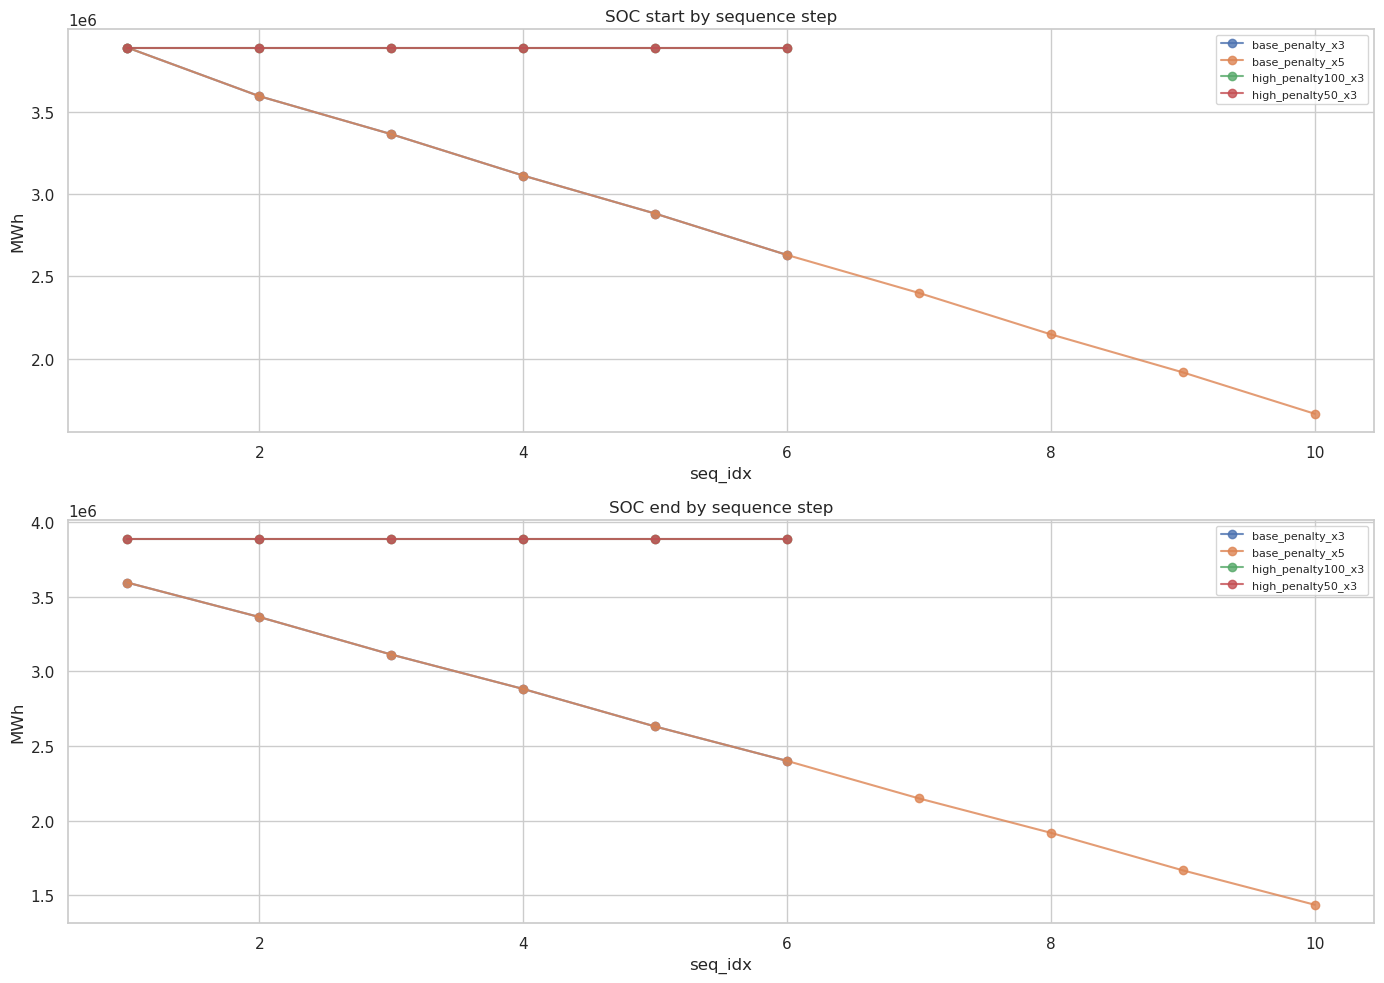

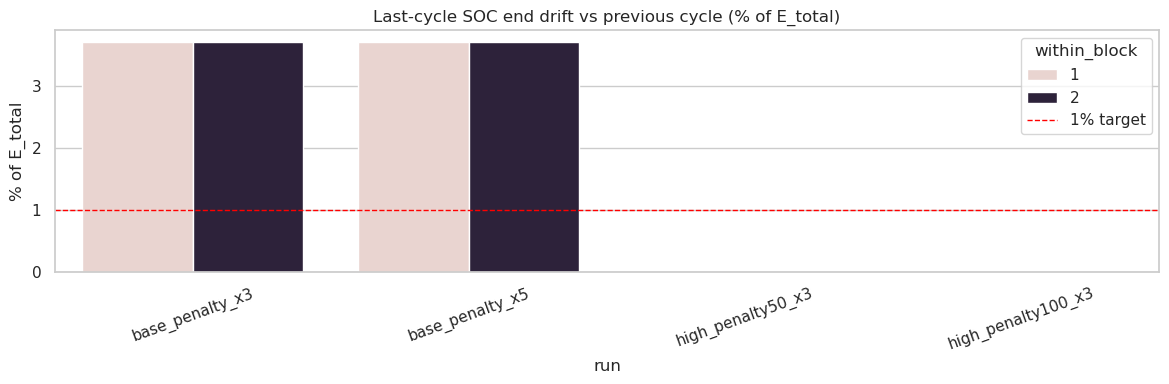

In [6]:
# Plots: SOC start/end drift and last-cycle SOC drift (%E)
plot_df = step_all.copy()
plot_df["slot"] = plot_df["within_block"].map({1: "slot1", 2: "slot2"}).fillna(plot_df["within_block"].astype(str))

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)
for lbl, grp in plot_df.groupby("run_label"):
    axes[0].plot(grp["seq_idx"], grp["soc_start_MWh"], marker="o", alpha=0.8, label=lbl)
axes[0].set_title("SOC start by sequence step")
axes[0].set_xlabel("seq_idx")
axes[0].set_ylabel("MWh")
axes[0].legend(fontsize=8)

for lbl, grp in plot_df.groupby("run_label"):
    axes[1].plot(grp["seq_idx"], grp["soc_end_MWh"], marker="o", alpha=0.8, label=lbl)
axes[1].set_title("SOC end by sequence step")
axes[1].set_xlabel("seq_idx")
axes[1].set_ylabel("MWh")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

if not conv_all.empty:
    last_cycle = conv_all.groupby("run")["cycle"].max().rename("last_cycle")
    tmp = conv_all.merge(last_cycle, on="run")
    last = tmp[tmp["cycle"] == tmp["last_cycle"]].copy()

    fig, ax = plt.subplots(figsize=(12,4))
    sns.barplot(data=last, x="run_label", y="d_soc_end_pct_E", hue="within_block", ax=ax)
    ax.axhline(1.0, color="red", linestyle="--", linewidth=1, label="1% target")
    ax.set_title("Last-cycle SOC end drift vs previous cycle (% of E_total)")
    ax.set_ylabel("% of E_total")
    ax.set_xlabel("run")
    ax.legend(title="within_block")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


In [7]:
# Optional: compact verdict table
if conv_all.empty:
    print("No convergence rows to evaluate.")
else:
    last_cycle = conv_all.groupby("run")["cycle"].max().rename("last_cycle")
    tmp = conv_all.merge(last_cycle, on="run")
    last = tmp[tmp["cycle"] == tmp["last_cycle"]].copy()

    verdict = last.groupby(["run", "run_label"]).agg(
        soc_ok=("soc_ok", "all"),
        throughput_ok=("throughput_ok", "all"),
        reliability_ok=("reliability_ok", "all"),
        all_ok=("all_ok", "all"),
        max_d_soc_start_pct_E=("d_soc_start_pct_E", "max"),
        max_d_soc_end_pct_E=("d_soc_end_pct_E", "max"),
    ).reset_index().sort_values("run_label")

    display(verdict.round(4))


,run,run_label,soc_ok,throughput_ok,reliability_ok,all_ok,max_d_soc_start_pct_E,max_d_soc_end_pct_E
0,stagel_3month_burnin_seq_8586x3,base_penalty_x3,False,True,True,False,3.7173,3.7173
3,stagel_3month_burnin_seq_8586x5,base_penalty_x5,False,True,True,False,3.7173,3.7173
1,stagel_3month_burnin_seq_8586x3_lamba_100,high_penalty100_x3,True,True,True,True,0.0000,0.0000
2,stagel_3month_burnin_seq_8586x3_lamba_50,high_penalty50_x3,True,True,True,True,0.0000,0.0000
